In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import EncoderNormalizer
from pytorch_forecasting.metrics import QuantileLoss
import lightning.pytorch as pl
from preprocess import load_data, preprocess_data


In [2]:
CONFIG = {
    "seed": 42,
    "data": {
        "train_path": "../../data/processed/residential4_energy_demand_daily_train.csv",
        "test_path": "../../data/processed/residential4_energy_demand_daily_test.csv",
        "lags": [1, 2, 3, 4],
        "val_size": 111,
        "val_ratio": None,
        "resolution": "daily",
    },
    "model": {
        # "network_arch": keras_LSTM_encoder_decoder,
        "network_params": {
            "encoder_units": 128,
            "decoder_units": 128,
            "dense_units": 128,
            "dropout": 0.2,
            "kernel_regularizer": {"l1": 0.01, "l2": 0.1},
        },
    },
    "training": {
        "epochs": 200,
        "lr": 0.0006,
        "batch_size": 8,
    },
    "wandb": {
        "entity": "ml-for-data-analytics-project",
        "project": "energy-forecasting",
        "run_name": "encdec_lstm_base",
        "enabled": False,
    },
}

In [4]:
seed = CONFIG.get("seed", 42)

train_df = load_data(CONFIG["data"]["train_path"])
test_df = load_data(CONFIG["data"]["test_path"])


train, test, concat, timestamps = preprocess_data(train_df, test_df)


In [78]:
from sklearn.preprocessing import RobustScaler

In [ ]:
pl.seed_everything(seed, workers=True)

MAX_ENC = 2 #look-back window (sequence length)
MAX_PRED = 1 #forecasting horizon

training = TimeSeriesDataSet(
    train, #slice of full dataset to be training set
    time_idx              = "day", #time_idx column
    target                = "energy_demand", #target column
    group_ids             = ["group_id"], #columns that uniquely identify different time series (e.g. different stores)
    max_encoder_length    = MAX_ENC,
    max_prediction_length = MAX_PRED,

    #specifying which features belong to which 'categories'
    time_varying_known_categoricals  = ["season", "is_holiday_or_weekend"],
    time_varying_unknown_reals       = [
        "energy_demand",
        "dishwasher", 
        "ev", 
        "freezer", 
        "grid_export", 
        "heat_pump", 
        "washing_machine", 
        "temperature", 
        "radiation_direct_horizontal", 
        "radiation_diffuse_horizontal"
    ],
    #encoder-based scaling adapts to level shifts in the target
    target_normalizer = EncoderNormalizer(method="robust", center=True)
)

validation = TimeSeriesDataSet.from_dataset( #validation set (here defined a bit different than in the lecture)
    training, concat, predict=False, min_prediction_idx = test.at[0, "day"], stop_randomization=True
)

Seed set to 42


In [126]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate          = 0.0001, #you can also try 0.0001, 0.01 etc, professional way: lr_find()
    hidden_size            = 32,   #start with 16/32, increase if not enough
    attention_head_size    = 1,    #usually 1-4
    dropout                = 0.2, #usually 0.1-0.3
    hidden_continuous_size = 4,   #set to <= hidden_size
    loss                   = QuantileLoss() #loss function for generating probabilistic forecasts
)

/Users/tomasz/PycharmProjects/ML/ML_for_Data_Analytics_Project/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/Users/tomasz/PycharmProjects/ML/ML_for_Data_Analytics_Project/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [128]:
csv_logger = pl.loggers.CSVLogger(save_dir="logs", name="tft")
#to log train/val losses - stored later e.g. in logs/my_tft_model/version_0/metrics.csv
#from this file, you can select "train_loss_epoch" and "val_loss" columns to plot train/val loss curves

trainer = pl.Trainer(
    max_epochs        = 100,
    gradient_clip_val = 0.01, #gradient clipping
    accelerator       = "mps", #<------"gpu" if GPU is available, else "cpu"
    log_every_n_steps = 5,
    enable_progress_bar = True,
    logger            = csv_logger,
    enable_checkpointing = False,
    callbacks=[
        pl.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            # restore_best_weights=True
        )
    ],
)

trainer.fit(
    tft,
    train_dataloaders = training.to_dataloader(train=True,  batch_size=8), #other batch_sizes may be better for your case (32, 128)
    val_dataloaders   = validation.to_dataloader(train=False, batch_size=8),
)

raw_preds = tft.predict(validation, mode="raw", return_x=True)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     14 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     80 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │      0 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  6.9 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │    294 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  4.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 61.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 61.8 K                                                                                               
Total estimated model params size (MB): 0.247                                                                      
Modules in train mode: 309                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/tomasz/PycharmProjects/ML/ML_for_Data_Analytics_Project/.venv/lib/python3.11/site-packages/lightning/pytorch
/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a 
bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to 
improve performance.

/Users/tomasz/PycharmProjects/ML/ML_for_Data_Analytics_Project/.venv/lib/python3.11/site-packages/lightning/pytorch
/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a 
bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to 
improve performance.

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


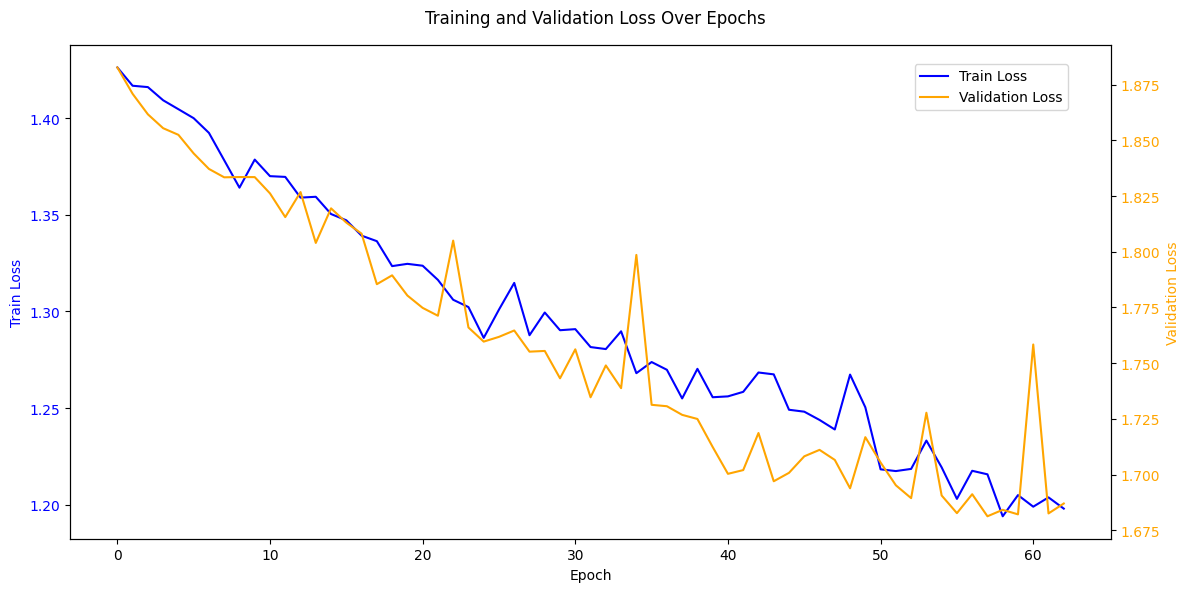

In [129]:
metrics = pd.read_csv("logs/tft/version_14/metrics.csv")
train_loss = metrics[metrics.train_loss_epoch.notna()][["epoch", "train_loss_epoch"]]
val_loss = metrics[metrics.val_loss.notna()][["epoch", "val_loss"]]

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(train_loss["epoch"], train_loss["train_loss_epoch"], label="Train Loss", color="blue")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")    
ax2 = ax1.twinx()
ax2.plot(val_loss["epoch"], val_loss["val_loss"], label="Validation Loss", color="orange")
ax2.set_ylabel("Validation Loss", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")  
fig.suptitle("Training and Validation Loss Over Epochs")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

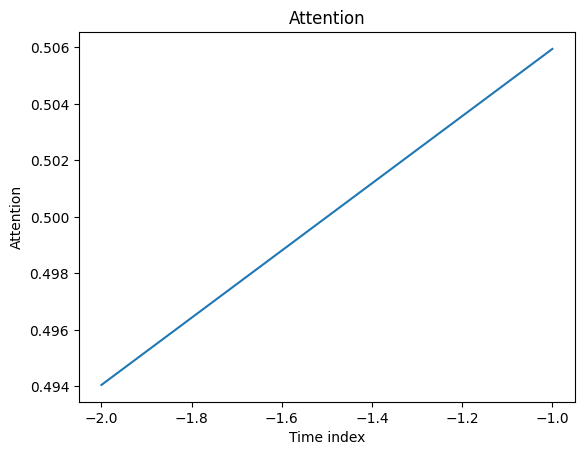

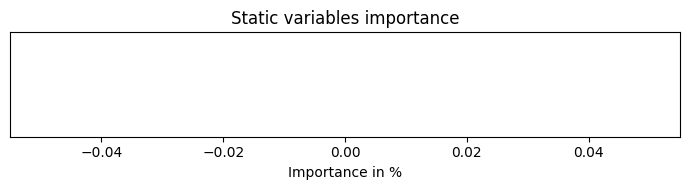

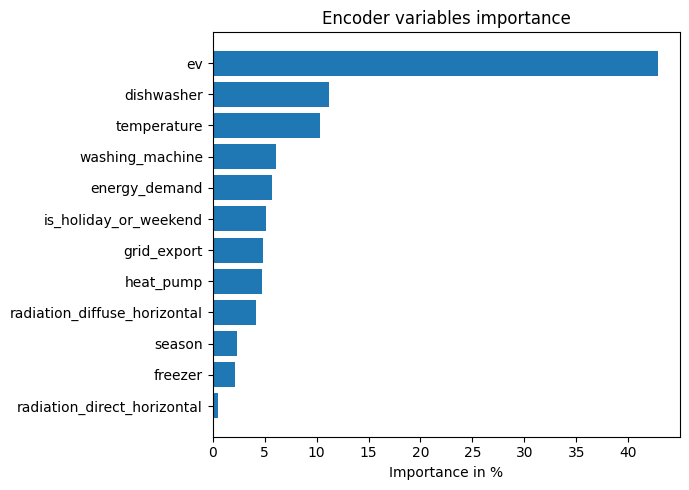

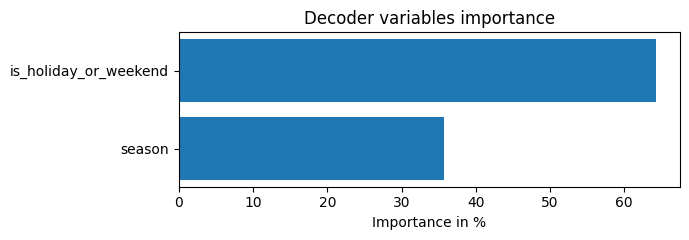

In [97]:
interpretation = tft.interpret_output(raw_preds.output, reduction="sum")
tft.plot_interpretation(interpretation)
plt.tight_layout(); plt.show()

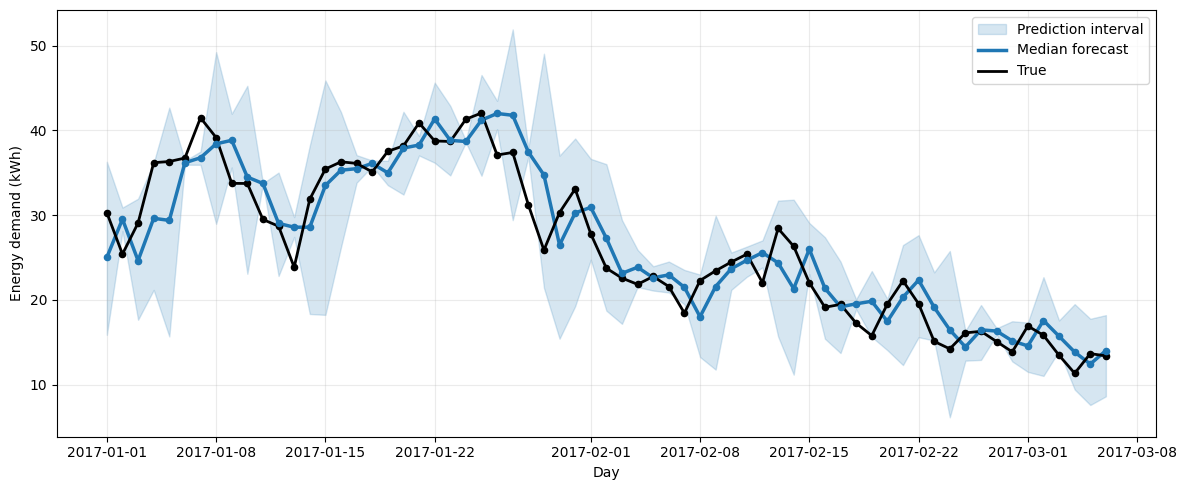

In [130]:
pred_index = validation.x_to_index(raw_preds.x)

true = raw_preds.x["decoder_target"]

# all prediction windows for that group
preds = raw_preds.output.prediction
index = pred_index

pred_1step = preds[:, 0].detach().cpu().numpy()
true_1step = true[:, 0].detach().cpu().numpy()

median = pred_1step[:, 3]
lower = pred_1step[:, 0]
upper = pred_1step[:, -1]

plt.figure(figsize=(12, 5))

# uncertainty band
plt.fill_between(
    timestamps[timestamps.dt.year == 2017],
    lower,
    upper,
    color="tab:blue",
    alpha=0.18,
    label="Prediction interval"
)

# median forecast
plt.plot(
    timestamps[timestamps.dt.year == 2017],
    median,
    color="tab:blue",
    linewidth=2.5,
    label="Median forecast"
)

# true values
plt.plot(
    timestamps[timestamps.dt.year == 2017],
    true_1step,
    color="black",
    linewidth=2,
    label="True"
)

plt.scatter(timestamps[timestamps.dt.year == 2017], true_1step, color="black", s=20, zorder=3)
plt.scatter(timestamps[timestamps.dt.year == 2017], median, color="tab:blue", s=20, zorder=3)

plt.xlabel("Day")
plt.ylabel("Energy demand (kWh)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [133]:
np.mean(np.abs(test["energy_demand"]-median)), np.mean(np.abs(true.ravel().numpy()-median)), np.mean((true.ravel().numpy()-median)**2)**.5

(np.float64(2.679351926637327), np.float32(2.6793518), np.float32(3.2749648))

In [136]:
train_preds.output.prediction[:, 0].detach().cpu().numpy()[:, 3].shape

(443,)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/tomasz/PycharmProjects/ML/ML_for_Data_Analytics_Project/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/tomasz/PycharmProjects/ML/ML_for_Data_Analytics_Project/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bot

(np.float64(17127.0), np.float64(17231.0))

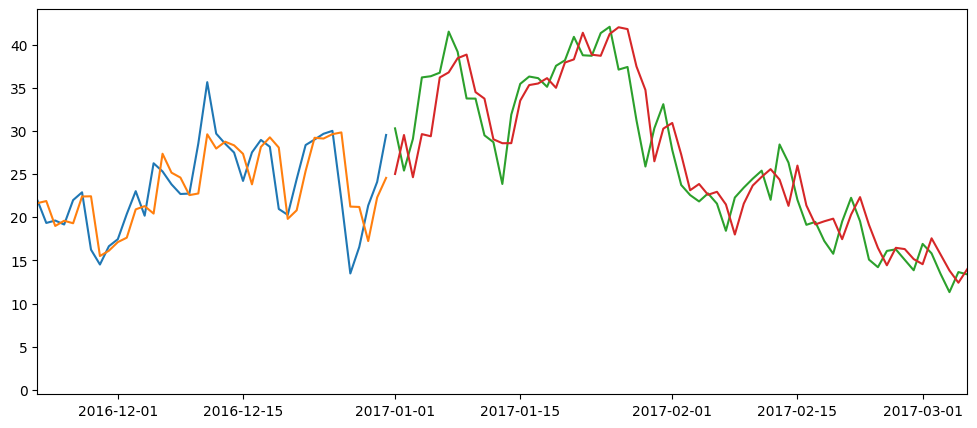

In [137]:
train_preds = tft.predict(training, mode="raw", return_x=True)
plt.figure(figsize=(12, 5))
plt.plot(train_df.index[2:], train_df["energy_demand"][2:])
plt.plot(train_df.index[2:], train_preds.output.prediction[:, 0].detach().cpu().numpy()[:, 3])
plt.plot(test_df.index, test_df["energy_demand"])
plt.plot(test_df.index, median)
plt.xlim(train_df.index[-40], test_df.index[-1])